In [1]:
import jax
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, tree_util
from functools import partial
from matplotlib import pyplot as plt
import diffrax as dif
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

jax.config.update("jax_enable_x64", True)

#Formulierung des Anfangswertproblems
f = lambda params, z, u: jnp.array([u[1], params[0] * u[0] + params[1] * jnp.sin(z)])

z0 = 0.
z1 = 40.
u0 = jnp.array([1., -0.5])
params = jnp.array([0.01, 0.505])

In [61]:
@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV2(params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(params, z0, dz, u0, f):
        k1 = dz * f(params, z0, u0)
        k2 = dz * f(params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1

    def rk4_step_scan(u, x):
        return rk4_step(params, x, dz, u, f), \
            rk4_step(params, x, dz, u, f)

    zs = jnp.linspace(z0, z1, n)
    _, uz = lax.scan(rk4_step_scan, u0, zs[:-1])
    uz = jnp.concatenate([jnp.array([u0]), uz], axis=0)

    return uz, zs

@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV3(params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(params, z0, dz, u0, f):
        k1 = dz * f(params, z0, u0)
        k2 = dz * f(params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1
    
    zs = jnp.linspace(z0, z1, n)

    def rk4_step_scan(i, uz):
        return rk4_step(params, zs[i], dz, uz, f)

    uz = lax.fori_loop(0, n-1, rk4_step_scan, u0)
    return uz, zs[-1]

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol', 'max_steps', 's']) 
def diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps, s=False):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(steps=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=max_steps)

    zs = sol.ts
    uz = sol.ys
    stats = sol.stats
    if s:
        return uz, zs, stats
    else:
        return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol', 's']) 
def diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol, s=False):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(ts=jnp.linspace(0, z1, n))
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys
    stats = sol.stats
    if s:
        return uz, zs, stats
    else:
        return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol', 'max_steps', 's']) 
def diffraxDopri5t1(params, z0, z1, u0, f, n, rtol, atol, max_steps, s=False):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(t1=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys
    stats = sol.stats
    if s:
        return uz, zs, stats
    else:
        return uz, zs

f_analytical = lambda z: jnp.cosh(0.1*z) - 0.5*jnp.sin(z)

def block_until_ready(pytree):
  return tree_util.tree_map(lambda x: x.block_until_ready(), pytree)

In [3]:
from scipy.optimize import curve_fit

def linreg(x,y,ey,ini=[1,1]):

    def func(x, m, b):
        return m*x + b
    
    popt, pcov = curve_fit(func, x, y, p0=ini, sigma=ey, absolute_sigma=True)
    perr = jnp.sqrt(jnp.diag(pcov))

    xi = y
    Xi = func(x, *popt)
    chiq = jnp.sum((xi-Xi)**2 / ey**2)
    ndof = len(xi)-2

    return popt[0], perr[0], popt[1], perr[1], chiq, ndof       



def residuenplot(var_x, unit_x, v_x, v_s_x, var_y, unit_y, v_y, v_s_y, m, b, chiq, name='', save=False, Zoom = None):
    
    fig, axarray = plt.subplots(2, 1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [5, 2]})
    plt.title(name)
    if Zoom != None:
        axarray[0].set_xlim(*Zoom)
        axarray[0].set_ylim(*Zoom)
    axarray[0].errorbar(v_x, v_y, xerr=v_s_x, yerr=v_s_y, color='red', fmt='o', markeredgecolor='red', label='Messwerte')
    axarray[0].set_xlabel('${0}$ / ${1}$'.format(var_x, unit_x))
    axarray[0].set_ylabel('${0}$ / ${1}$'.format(var_y, unit_y))
    axarray[0].plot(v_x, m*v_x+b, color='green', label='${0:.2f}*x+{1:.2f}$'.format(m, b))
    sigmaRes = jnp.sqrt((m*v_s_x)**2 + v_s_y**2)
    axarray[1].axhline(y=0., color='black', linestyle='--')
    axarray[1].errorbar(v_x, v_y-(m*v_x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
    axarray[1].set_xlabel('${0}$ / ${1}$'.format(var_x, unit_x))
    axarray[1].set_ylabel('Residuen')
    plt.figtext(0.14,0.7,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(v_x)-2, chiq/(len(v_x)-2)))
    axarray[0].legend()
    axarray[0].grid()
    ymax = max([abs(x) for x in axarray[1].get_ylim()])
    axarray[1].set_ylim(-ymax, ymax)
    plt.tight_layout()
    plt.grid()
    fig.subplots_adjust(hspace=0.0)
    
    if save == True:
        plt.savefig(name)
    
    plt.show() 

In [145]:
# ns = [100, 200, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 12000, 25000, 50000, 70000, 80000]

# df_e = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

# for n in ns:
#     uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
#     t = %timeit -n500 -o block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))

#     abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
#     abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
#     abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

#     df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)

# df_e.to_string('Plots/benchmark_eigen3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

11.6 µs ± 461 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
15 µs ± 341 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
26.2 µs ± 261 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_12468\975002789.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


35.3 µs ± 372 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
44.4 µs ± 1.05 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
68.2 µs ± 3.89 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
81.7 µs ± 868 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
119 µs ± 1.29 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
154 µs ± 1.47 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
190 µs ± 2.07 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
237 µs ± 9.29 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
448 µs ± 13.2 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
910 µs ± 2.86 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
2.01 ms ± 14.2 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
2.8 ms ± 32.1 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
3.18 ms ± 31.4 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)


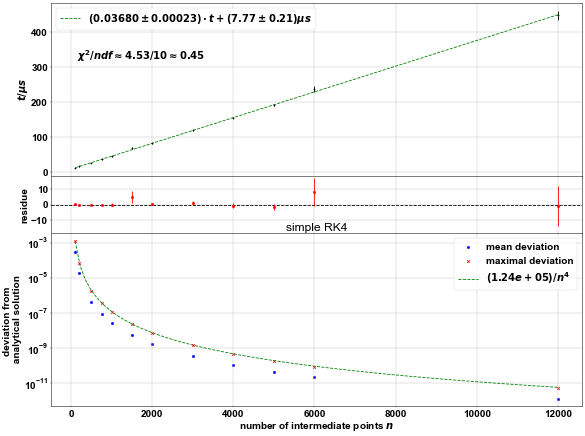

In [193]:
# # Plot
# end = -4
# x = jnp.array(df_e['n'].to_numpy(), dtype=jnp.float32)
# y = jnp.array(df_e['t_mean'])*1e+6
# ey = jnp.array(df_e['t_std'])*1e+6
# n = df_e['n']
# abwmean = df_e['abw_mean_eigen']
# abwmax = df_e['abw_max_eigen']
# m, em, b, eb, chiq, ndof = linreg(x[:-5], y[:-5], ey[:-5], ini=[1,1])
# x = x[:end]
# y = y[:end]
# ey = ey[:end]
# n = n[:end]
# abwmean = abwmean[:end]
# abwmax = abwmax[:end]

# popt, pcov = curve_fit(lambda x, m: m/x**4, n, abwmax)

# fig, ax = plt.subplots(3,1, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3]})
# plt.title('simple RK4')
# ax[0].set_ylabel('$t/\mu s$')
# ax[0].errorbar(x, y, yerr=ey, color='black', fmt = '.')
# ax[0].plot(x, m*x+b, color='green', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m, b, em, eb))
# # ax[0].plot(x, m2*x+b2, color='blue', linestyle='--', label='$({0:.4f} \pm {2:.4f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m2, b2, em2, eb2))
# ax[0].grid()
# ax[0].legend()
# sigmaRes = ey
# ax[1].axhline(y=0., color='black', linestyle='--')
# ax[1].errorbar(x, y-(m*x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
# # ax[1].errorbar(x, y-(m2*x+b2), yerr=sigmaRes, color='blue', fmt='o', markeredgecolor='blue')
# ax[1].set_ylabel('residue')
# plt.figtext(0.14,0.85, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq, len(x)-2, chiq/(len(x)-2)))
# # plt.figtext(0.14,0.85,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(x[:-7])-2, chiq/(len(x[:-7])-2)))
# # plt.figtext(0.14,0.80,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq2, len(x[-7:-2])-2, chiq2/(len(x[-7:-2])-2)))
# ax[1].grid()
# ymax = max([abs(x) for x in ax[1].get_ylim()])
# ax[1].set_ylim(-ymax, ymax)
# ax[2].set_xlabel('number of intermediate points $n$')
# ax[2].set_ylabel('deviation from \n analytical solution')
# ax[2].set_yscale('log')
# ax[2].scatter(n, abwmean, color='blue', label='mean deviation', marker='o')
# ax[2].scatter(n, abwmax, color='red', label='maximal deviation', marker='x')
# ns = jnp.linspace(n[0], n[len(n)-1], 100)
# ax[2].plot(ns, popt[0]/ns**4, color='green', linestyle='--', label='$({0:.2e})/n^4$'.format(popt[0]))
# ax[2].grid()
# ax[2].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_eigen3.png')
# fig.set_dpi(30)


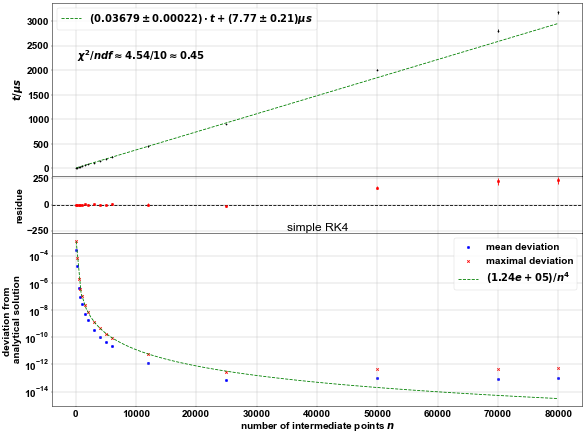

In [192]:
# # Plot
# end = None
# x = jnp.array(df_e['n'].to_numpy(), dtype=jnp.float32)
# y = jnp.array(df_e['t_mean'])*1e+6
# ey = jnp.array(df_e['t_std'])*1e+6
# n = df_e['n']
# abwmean = df_e['abw_mean_eigen']
# abwmax = df_e['abw_max_eigen']
# m, em, b, eb, chiq, ndof = linreg(x[:-4], y[:-4], ey[:-4], ini=[1,1])
# x = x[:end]
# y = y[:end]
# ey = ey[:end]
# n = n[:end]
# abwmean = abwmean[:end]
# abwmax = abwmax[:end]

# popt, pcov = curve_fit(lambda x, m: m/x**4, n, abwmax)

# fig, ax = plt.subplots(3,1, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3]})
# plt.title('simple RK4')
# ax[0].set_ylabel('$t/\mu s$')
# ax[0].errorbar(x, y, yerr=ey, color='black', fmt = '.')
# ax[0].plot(x, m*x+b, color='green', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m, b, em, eb))
# # ax[0].plot(x, m2*x+b2, color='blue', linestyle='--', label='$({0:.4f} \pm {2:.4f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m2, b2, em2, eb2))
# ax[0].grid()
# ax[0].legend()
# sigmaRes = ey
# ax[1].axhline(y=0., color='black', linestyle='--')
# ax[1].errorbar(x, y-(m*x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
# # ax[1].errorbar(x, y-(m2*x+b2), yerr=sigmaRes, color='blue', fmt='o', markeredgecolor='blue')
# ax[1].set_ylabel('residue')
# plt.figtext(0.14,0.85, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq, len(x[:-4])-2, chiq/(len(x[:-4])-2)))
# # plt.figtext(0.14,0.85,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(x[:-7])-2, chiq/(len(x[:-7])-2)))
# # plt.figtext(0.14,0.80,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq2, len(x[-7:-2])-2, chiq2/(len(x[-7:-2])-2)))
# ax[1].grid()
# ymax = max([abs(x) for x in ax[1].get_ylim()])
# ax[1].set_ylim(-ymax, ymax)
# ax[2].set_xlabel('number of intermediate points $n$')
# ax[2].set_ylabel('deviation from \n analytical solution')
# ax[2].set_yscale('log')
# ax[2].scatter(n, abwmean, color='blue', label='mean deviation', marker='o')
# ax[2].scatter(n, abwmax, color='red', label='maximal deviation', marker='x')
# ns = jnp.linspace(n[0], n[len(n)-1], 100)
# ax[2].plot(ns, popt[0]/ns**4, color='green', linestyle='--', label='$({0:.2e})/n^4$'.format(popt[0]))
# ax[2].grid()
# ax[2].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_eigen3_more_local.png')
# fig.set_dpi(30)

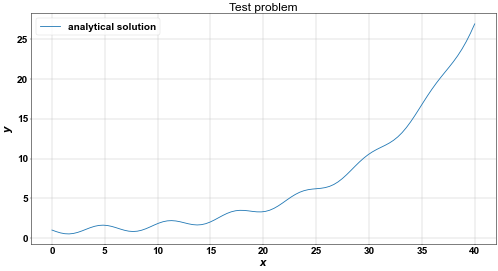

In [196]:
# fig, ax = plt.subplots(1,1, figsize=(20,10))
# plt.title('Test problem')
# ax.set_xlabel('$x$')
# ax.set_ylabel('$y$')
# zz = jnp.linspace(z0, z1, 100)
# # plt.plot(zs_eigen, uz_eigen[:,0], label='Eigen')
# plt.plot(zz, f_analytical(zz), label='analytical solution', linestyle='-')
# plt.legend()
# plt.grid()
# plt.savefig('Plots/test_problem.png')
# fig.set_dpi(30)
# plt.show()

In [181]:
# ns = [100, 200, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 12000, 25000, 50000, 70000, 80000]

# df_e_ = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

# for n in ns:
#     uz_eigen, zs_eigen = eigenerSolverV3(params, z0, z1, u0, f, n)
#     t = %timeit -n500 -o block_until_ready(eigenerSolverV3(params, z0, z1, u0, f, n))

#     abw_eigen = jnp.array([uz_eigen[0] - f_analytical(zs_eigen)])
#     abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
#     abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

#     df_e_ = pd.concat([df_e_, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)

# df_e_.to_string('Plots/benchmark_eigen3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

9.38 µs ± 320 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
10.7 µs ± 223 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
15.6 µs ± 386 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
19.4 µs ± 233 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_12468\3232218351.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e_ = pd.concat([df_e_, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


24 µs ± 833 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
30.6 µs ± 409 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
38.6 µs ± 740 ns per loop (mean ± std. dev. of 7 runs, 500 loops each)
56.1 µs ± 3.15 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
70.4 µs ± 1.08 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
85.6 µs ± 2.1 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
101 µs ± 1.13 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
199 µs ± 9.06 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
393 µs ± 4.63 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
782 µs ± 6.74 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
1.12 ms ± 6.65 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
1.27 ms ± 3.87 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)


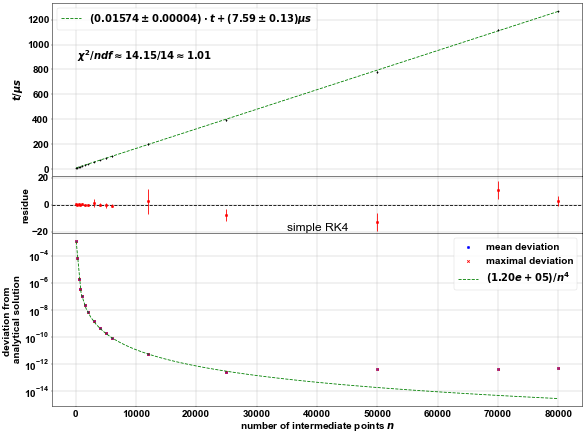

In [303]:
# # Plot
# end = None
# x = jnp.array(df_e_['n'].to_numpy(), dtype=jnp.float32)
# y = jnp.array(df_e_['t_mean'])*1e+6
# ey = jnp.array(df_e_['t_std'])*1e+6
# n = df_e_['n']
# abwmean = df_e_['abw_mean_eigen']
# abwmax = df_e_['abw_max_eigen']
# m, em, b, eb, chiq, ndof = linreg(x[:end], y[:end], ey[:end], ini=[1,1])
# # m2, em2, b2, eb2, chiq2, ndof2 = linreg(x[-7:-2], y[-7:-2], ey[-7:-2], ini=[1,1])
# # m, em, b, eb, chiq, ndof = linreg(x, y, ey, ini=[1,1])
# x = x[:end]
# y = y[:end]
# ey = ey[:end]
# n = n[:end]
# abwmean = abwmean[:end]
# abwmax = abwmax[:end]

# popt, pcov = curve_fit(lambda x, m: m/x**4, n, abwmax, sigma=abwmax)

# fig, ax = plt.subplots(3,1, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3]})
# plt.title('simple RK4')
# ax[0].set_ylabel('$t/\mu s$')
# ax[0].errorbar(x, y, yerr=ey, color='black', fmt = '.')
# ax[0].plot(x, m*x+b, color='green', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m, b, em, eb))
# # ax[0].plot(x, m2*x+b2, color='blue', linestyle='--', label='$({0:.4f} \pm {2:.4f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m2, b2, em2, eb2))
# ax[0].grid()
# ax[0].legend()
# sigmaRes = ey
# ax[1].axhline(y=0., color='black', linestyle='--')
# ax[1].errorbar(x, y-(m*x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
# # ax[1].errorbar(x, y-(m2*x+b2), yerr=sigmaRes, color='blue', fmt='o', markeredgecolor='blue')
# ax[1].set_ylabel('residue')
# plt.figtext(0.14,0.85, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq, len(x[:end])-2, chiq/(len(x[:end])-2)))
# # plt.figtext(0.14,0.85,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(x[:-7])-2, chiq/(len(x[:-7])-2)))
# # plt.figtext(0.14,0.80,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq2, len(x[-7:-2])-2, chiq2/(len(x[-7:-2])-2)))
# ax[1].grid()
# ymax = max([abs(x) for x in ax[1].get_ylim()])
# ax[1].set_ylim(-ymax, ymax)
# ax[2].set_xlabel('number of intermediate points $n$')
# ax[2].set_ylabel('deviation from \n analytical solution')
# ax[2].set_yscale('log')
# ax[2].scatter(n, abwmean, color='blue', label='mean deviation', marker='o')
# ax[2].scatter(n, abwmax, color='red', label='maximal deviation', marker='x')
# ns = jnp.linspace(n[0], n[len(n)-1], 100)
# ax[2].plot(ns, popt[0]/ns**4, color='green', linestyle='--', label='$({0:.2e})/n^4$'.format(popt[0]))
# ax[2].grid()
# ax[2].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_eigen3_last.png')
# fig.set_dpi(30)

In [230]:
rtol = 0
atols = [1e-1]

df_dat = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for atol in atols:
    uz_dopri, zs_dopri, stats = diffraxDopri5t1(params, z0, z1, u0, f, 0, rtol, atol, 4096, True)
    print(stats)

{'max_steps': None, 'num_accepted_steps': Array(10, dtype=int64, weak_type=True), 'num_rejected_steps': Array(1, dtype=int64, weak_type=True), 'num_steps': Array(11, dtype=int64, weak_type=True)}


In [237]:
# rtol = 0
# atols = [1e-3, 1e-6, 1e-7, 1e-8, 1e-9, 3e-10, 5e-10, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15, 1e-16, 1e-17, 1e-18]

# df_dat = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n_acc', 'n_rej', 't_mean', 't_std'])

# for atol in atols:
#     uz_dopri, zs_dopri, stats = diffraxDopri5t1(params, z0, z1, u0, f, 0, rtol, atol, 4096, True)
#     _, _ = diffraxDopri5t1(params, z0, z1, u0, f, 0, rtol, atol, 4096)
#     t = %timeit -n500 -o block_until_ready(diffraxDopri5t1(params, z0, z1, u0, f, 0, rtol, atol, 4096))

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
#     abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

#     steps_acc = stats['num_accepted_steps']
#     steps_rej = stats['num_rejected_steps']

#     df_dat = pd.concat([df_dat, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n_acc': [steps_acc], 'n_rej': [steps_rej], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



# df_dat.to_string('Plots/benchmark_dopria3t1.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

180 µs ± 6.25 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_12248\3095292683.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dat = pd.concat([df_dat, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n_acc': [steps_acc], 'n_rej': [steps_rej], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


195 µs ± 2.66 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
207 µs ± 3.35 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
226 µs ± 3.54 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
256 µs ± 2.15 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
275 µs ± 2.19 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
269 µs ± 1.82 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
303 µs ± 3.94 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
371 µs ± 2.63 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
479 µs ± 3.64 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
655 µs ± 5.67 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
931 µs ± 5.4 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
1.38 ms ± 17.3 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
2.04 ms ± 2.14 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
3.12 ms ± 9.29 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
4.85

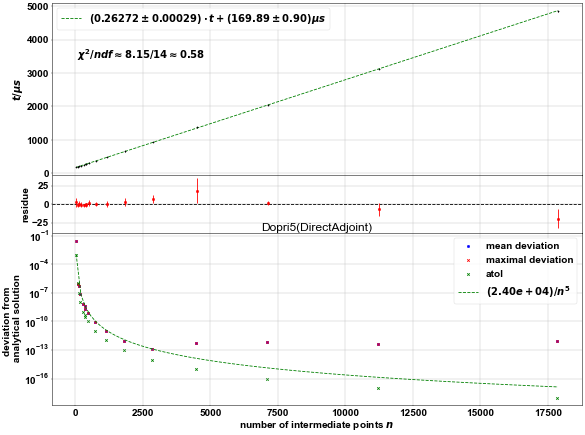

In [239]:
# # Plot
# end = None
# atol = jnp.array(df_dat['atol'].to_numpy(), dtype=jnp.float64)
# y = jnp.array(df_dat['t_mean'])*1e+6
# ey = jnp.array(df_dat['t_std'])*1e+6
# n_acc = jnp.array(df_dat['n_acc'].to_numpy(), dtype=jnp.float64)
# n_rej = jnp.array(df_dat['n_rej'].to_numpy(), dtype=jnp.float64)
# abwmean = jnp.array(df_dat['abw_mean_dopri'].to_numpy(), dtype=jnp.float64)
# abwmax = jnp.array(df_dat['abw_max_dopri'].to_numpy(), dtype=jnp.float64)
# x = n_acc+n_rej

# x = x[:end]+1
# y = y[:end]
# ey = ey[:end]
# n_acc = n_acc[:end]+1
# n_rej = n_rej[:end]
# abwmean = abwmean[:end]
# abwmax = abwmax[:end]

# m, em, b, eb, chiq, ndof = linreg(x, y, ey, ini=[1,1])

# popt, pcov = curve_fit(lambda xx, m: m/xx**5, n_acc[:-4], abwmax[:-4], sigma=abwmax[:-4]**2)

# fig, ax = plt.subplots(3,1, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3]})
# plt.title('Dopri5(DirectAdjoint)')
# ax[0].set_ylabel('$t/\mu s$')
# ax[0].errorbar(x, y, yerr=ey, color='black', fmt = '.')
# ax[0].plot(x, m*x+b, color='green', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m, b, em, eb))
# ax[0].grid()
# ax[0].legend()
# sigmaRes = ey
# ax[1].axhline(y=0., color='black', linestyle='--')
# ax[1].errorbar(x, y-(m*x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
# ax[1].set_ylabel('residue')
# plt.figtext(0.14,0.85, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq, len(x)-2, chiq/(len(x)-2)))
# ax[1].grid()
# ymax = max([abs(x) for x in ax[1].get_ylim()])
# ax[1].set_ylim(-ymax, ymax)
# ax[2].set_xlabel('number of intermediate points $n$')
# ax[2].set_ylabel('deviation from \n analytical solution')
# ax[2].set_yscale('log')
# ax[2].scatter(n_acc, abwmean, color='blue', label='mean deviation', marker='o')
# ax[2].scatter(n_acc, abwmax, color='red', label='maximal deviation', marker='x')
# ax[2].scatter(n_acc, atol, color='green', label='atol', marker='x')
# ns = jnp.linspace(x[0], x[len(x)-1], 100)
# ax[2].plot(ns, popt[0]/ns**5, color='green', linestyle='--', label='$({0:.2e})/n^5$'.format(popt[0]))
# ax[2].grid()
# ax[2].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_dopri_t1.png')
# fig.set_dpi(30)

In [364]:
# rtol = 0
# atols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 2e-10, 3e-10, 5e-10, 7e-10, 1e-10]

# df_da = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

# for atol in atols:
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, 4096)
#     t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, 4096))

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
#     abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

#     df_da = pd.concat([df_da, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



# df_da.to_string('Plots/benchmark_dopria3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)


In [363]:
# # Plot
# fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
# plt.title('Dopri5(DirectAdjoint) rtol=0')
# ax[0].set_ylabel('$t/s$')
# ax[0].errorbar(df_da['atol'], df_da['t_mean'], yerr=df_da['t_std'], color='black', fmt = '.')
# ax[0].grid()
# ax[1].set_ylabel('Abweichung truth')
# ax[1].set_yscale('log')
# ax[1].scatter(df_da['atol'], df_da['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_da['atol'], df_da['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
# ax[1].grid()
# ax[1].legend()
# ax[2].set_xlabel('atol')
# ax[2].set_xscale('log')
# ax[2].set_ylabel('n')
# ax[2].scatter(df_da['atol'], df_da['n'], color='green', marker='o')
# ax[2].grid()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_dopria3.png')

In [361]:
# rtols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 2e-9, 3e-9, 5e-9, 7e-9, 1e-9]
# atol = 0

# df_dr = pd.DataFrame(columns=['rtol', 'rel_abw_mean_dopri', 'rel_abw_max_dopri', 'n', 't_mean', 't_std'])

# for rtol in rtols:
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, 4096)
#     t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, 4096))

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     rel_abw_dopri = jnp.array([(uz_dopri[i,0] - f_analytical(zs_dopri[i]) )/f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     rel_abw_mean_dopri = jnp.mean(jnp.abs(rel_abw_dopri))
#     rel_abw_max_dopri = jnp.max(jnp.abs(rel_abw_dopri))

#     df_dr = pd.concat([df_dr, pd.DataFrame({'rtol':[rtol], 'rel_abw_mean_dopri': [rel_abw_mean_dopri], 'rel_abw_max_dopri': [rel_abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



# df_dr.to_string('Plots/benchmark_doprir3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

In [362]:
# # Plot
# fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
# plt.title('Dopri5(DirectAdjoint) rtol=0')
# ax[0].set_ylabel('$t/s$')
# #ax[0].set_yscale('log')
# ax[0].errorbar(df_dr['rtol'], df_dr['t_mean'], yerr=df_dr['t_std'], color='black', fmt = '.')
# ax[0].grid()
# ax[1].set_ylabel('rel. Abweichung truth')
# ax[1].set_yscale('log')
# ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_max_dopri'], color='red', label='Maximalwert', marker='x')
# ax[1].grid()
# ax[1].legend()
# ax[2].set_xlabel('rtol')
# ax[2].set_xscale('log')
# ax[2].set_ylabel('n')
# ax[2].scatter(df_dr['rtol'], df_dr['n'], color='green', marker='o')
# ax[2].grid()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

In [45]:
# ns = [100, 200, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 12000, 25000, 50000, 70000, 80000]
# rtol = 0
# atol1 = 1e-6
# atol2 = 1e-12

# df_dn = pd.DataFrame(columns=['abw_mean_dopri', 'abw_max_dopri', 'n', 'n_acc', 'n_rej', 't_mean', 't_std', 'atol'])

# for n in ns:
#     uz_doprin, zs_doprin, stats = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol1, True)
#     _, _ = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol1)
#     t = %timeit -n500 -o block_until_ready(diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol1))

#     abw_doprin = jnp.array([uz_doprin[i,0] - f_analytical(zs_doprin[i]) for i in range(n)])
#     abw_mean_doprin = jnp.mean(jnp.abs(abw_doprin))
#     abw_max_doprin = jnp.max(jnp.abs(abw_doprin))
#     n_acc = stats['num_accepted_steps']
#     n_rej = stats['num_rejected_steps']

#     df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 'n_acc': [n_acc], 'n_rej': [n_rej], 't_mean': [t.average], 't_std': [t.stdev], 'atol': [atol1]})], ignore_index=True)

# for n in ns:
#     uz_doprin, zs_doprin, stats = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol2, True)
#     _, _ = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol2)
#     t = %timeit -n500 -o block_until_ready(diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol2))

#     abw_doprin = jnp.array([uz_doprin[i,0] - f_analytical(zs_doprin[i]) for i in range(n)])
#     abw_mean_doprin = jnp.mean(jnp.abs(abw_doprin))
#     abw_max_doprin = jnp.max(jnp.abs(abw_doprin))
#     n_acc = stats['num_accepted_steps']
#     n_rej = stats['num_rejected_steps']

#     df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 'n_acc': [n_acc], 'n_rej': [n_rej], 't_mean': [t.average], 't_std': [t.stdev], 'atol': [atol2]})], ignore_index=True)



# df_dn.to_string('Plots/benchmark_doprin3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

203 µs ± 9.65 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_12248\1164720784.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 'n_acc': [n_acc], 'n_rej': [n_rej], 't_mean': [t.average], 't_std': [t.stdev], 'atol': [atol1]})], ignore_index=True)


198 µs ± 2.33 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
200 µs ± 2.48 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
206 µs ± 2.48 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
204 µs ± 2.02 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
210 µs ± 2.28 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
215 µs ± 2.66 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
224 µs ± 2 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
231 µs ± 2.87 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
242 µs ± 2.17 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
253 µs ± 5.64 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
301 µs ± 2.75 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
423 µs ± 10.6 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
759 µs ± 6.18 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
1.11 ms ± 5.38 µs per loop (mean ± std. dev. of 7 runs, 500 loops each)
1.21 ms 

[  100.   200.   500.   750.  1000.  1500.  2000.  3000.  4000.  5000.
  6000. 12000. 25000. 50000. 70000. 80000.   100.   200.   500.   750.
  1000.  1500.  2000.  3000.  4000.  5000.  6000. 12000. 25000. 50000.
 70000. 80000.]
[  99.   99.   99.   99.   99.   99.   99.   99.   99.   99.   99.   99.
   99.   99.   99.   99. 1176. 1176. 1176. 1176. 1176. 1176. 1176. 1176.
 1176. 1176. 1176. 1176. 1176. 1176. 1176. 1176.]


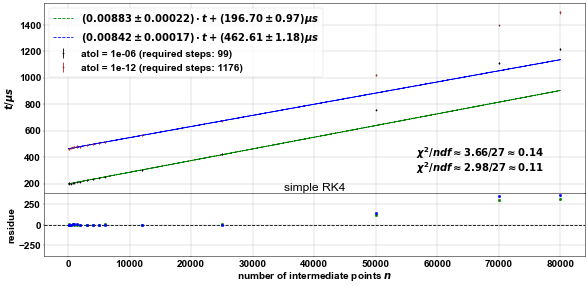

In [55]:
# # Plot
# x = jnp.array(df_dn['n'].to_numpy(), dtype=jnp.float64)
# y = jnp.array(df_dn['t_mean'])*1e+6
# ey = jnp.array(df_dn['t_std'])*1e+6
# abwmean = jnp.array(df_dn['abw_mean_dopri'].to_numpy(), dtype=jnp.float64)
# abwmax = jnp.array(df_dn['abw_max_dopri'].to_numpy(), dtype=jnp.float64)
# n_acc = jnp.array(df_dn['n_acc'].to_numpy(), dtype=jnp.float64)
# n_rej = jnp.array(df_dn['n_rej'].to_numpy(), dtype=jnp.float64)
# n = n_acc+n_rej
# atol = jnp.array(df_dn['atol'].to_numpy(), dtype=jnp.float64)
# print(x)
# print(n)

# where1 = jnp.where(atol == atol1)
# x1 = x[where1]
# y1 = y[where1]
# ey1 = ey[where1]
# n1 = n[where1]
# abwmean1 = abwmean[where1]
# abwmax1 = abwmax[where1]
# n1 = n[where1]

# where2 = jnp.where(atol == atol2)
# x2 = x[where2]
# y2 = y[where2]
# ey2 = ey[where2]
# n2 = n[where2]
# abwmean2 = abwmean[where2]
# abwmax2 = abwmax[where2]
# n2 = n[where2]

# m1, em1, b1, eb1, chiq1, ndof1 = linreg(x1[:-3], y1[:-3], ey1[:-3], ini=[1,1])
# m2, em2, b2, eb2, chiq2, ndof2 = linreg(x2[:-3], y2[:-3], ey2[:-3], ini=[1,1])


# fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
# plt.title('simple RK4')
# ax[0].set_ylabel('$t/\mu s$')
# ax[0].errorbar(x1, y1, yerr=ey1, color='black', fmt = '.', label=f'atol = {atol1:.0e} (required steps: {n1[0]:.0f})')
# ax[0].errorbar(x2, y2, yerr=ey2, color='brown', fmt = '.', label=f'atol = {atol2:.0e} (required steps: {n2[0]:.0f})')
# ax[0].plot(x, m1*x+b1, color='green', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m1, b1, em1, eb1))
# ax[0].plot(x, m2*x+b2, color='blue', linestyle='--', label='$({0:.5f} \pm {2:.5f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m2, b2, em2, eb2))
# ax[0].grid()
# ax[0].legend()
# ax[1].axhline(y=0., color='black', linestyle='--')
# ax[1].errorbar(x1, y1-(m1*x1+b1), yerr=ey1, color='green', fmt='o', markeredgecolor='green')
# ax[1].errorbar(x2, y2-(m2*x2+b2), yerr=ey2, color='blue', fmt='o', markeredgecolor='blue')
# ax[1].set_ylabel('residue')
# plt.figtext(0.70,0.45, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq1, len(x[:-3])-2, chiq1/(len(x[:-3])-2)))
# plt.figtext(0.70,0.40, rf'$\chi^2/ndf \approx %.2f / %.0f \approx %.2f$' % (chiq2, len(x[:-3])-2, chiq2/(len(x[:-3])-2)))
# ax[1].grid()
# ymax = max([abs(x) for x in ax[1].get_ylim()])
# ax[1].set_ylim(-ymax, ymax)
# ax[1].set_xlabel('number of intermediate points $n$')
# # ax[2].set_ylabel('deviation from \n analytical solution')
# # ax[2].set_yscale('log')
# # ax[2].scatter(x1, abwmax1, color='black', label=f'maximal deviation atol = {atol1:.0f}', marker='x')
# # ax[2].scatter(x2, abwmax2, color='brown', label=f'maximal deviation atol = {atol2:.0f}', marker='x')
# # ax[2].axhline(y=atol1, color='black', linestyle='--', label=f'atol = {atol1:.0e}')
# # ax[2].axhline(y=atol2, color='brown', linestyle='--', label=f'atol = {atol2:.0e}')
# # ax[2].grid()
# # ax[2].legend()
# # ax[2].set_ylim(1e-14, 1e-4)
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_doprin3.png')
# fig.set_dpi(30)

In [168]:
# rtol = 0
# atol = 1e-6
# max_steps_ = [256, 512, 1024, 2048,     4096, 8192, 16384, 32768,       65636, 131072, 262144, 524288,      1048576, 2097152, 4194304, 8388608,     16777216, 33554432, 67108864, 134217728,    268435456, 536870912, 1073741824]


# df_ds = pd.DataFrame(columns=['max_steps', 'abw_mean_dopri', 'abw_max_dopri', 'n', 'n_acc', 'n_rej', 't_mean', 't_std'])

# for max_steps in max_steps_:
#     uz_dopri, zs_dopri, stats = diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, max_steps, True)
#     _, _ = diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, max_steps)
#     t = %timeit -n10 -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, 0, rtol, atol, max_steps))

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
#     abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

#     n_acc = stats['num_accepted_steps']
#     n_rej = stats['num_rejected_steps']

#     df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 'n_acc': [n_acc], 'n_rej': [n_rej],  't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



# df_ds.to_string('Plots/benchmark_dopris3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

253 µs ± 61.7 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
211 µs ± 32.2 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
224 µs ± 14 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
279 µs ± 45.7 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
233 µs ± 31.1 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
241 µs ± 27.5 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_12248\3425674801.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 'n_acc': [n_acc], 'n_rej': [n_rej],  't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


287 µs ± 40.5 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
329 µs ± 33.4 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
490 µs ± 16.6 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
962 µs ± 61.3 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.25 ms ± 111 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.98 ms ± 82.3 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.66 ms ± 547 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
3.79 ms ± 25.1 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.72 ms ± 1.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
17.5 ms ± 3.76 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
31.9 ms ± 5.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
65.6 ms ± 3.97 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
128 ms ± 6.59 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
256 ms ± 6.54 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
514 ms ± 4.16 

11.127887423035006 12 1.1127887423035006
1.498572001059236 4 0.749286000529618
4.290734987374301 11 0.4767483319304779


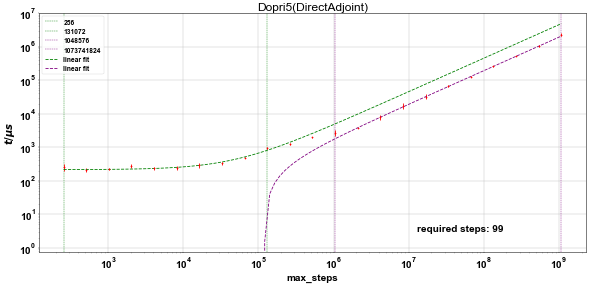

In [221]:
# # Plot
# fig, ax = plt.subplots(1,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3]})
# ax = [ax]
# plt.title('Dopri5(DirectAdjoint)')
# ax[0].set_ylabel('$t/\mu s$')
# # ax[0].axvline(x=16**2, color='black', linestyle='--', label=f'{16**2:.0f}', linewidth = 1)
# # ax[0].axvline(x=16**3, color='black', linestyle='--', label=f'{16**3:.0f}', linewidth = 1)
# # ax[0].axvline(x=16**4, color='black', linestyle='--', label=f'{16**4:.0f}', linewidth = 1)
# # ax[0].axvline(x=16**5, color='black', linestyle='--', label=f'{16**5:.0f}', linewidth = 1)
# # ax[0].axvline(x=16**6, color='black', linestyle='--', label=f'{16**6:.0f}', linewidth = 1)
# # ax[0].axvline(x=16**7, color='black', linestyle='--', label=f'{16**7:.0f}', linewidth = 1)
# x = jnp.array(df_ds['max_steps'].to_numpy(), dtype=jnp.float64)
# y = jnp.array(df_ds['t_mean'].to_numpy(), dtype=jnp.float64)*1e+6
# ey = jnp.array(df_ds['t_std'].to_numpy(), dtype=jnp.float64)*1e+6
# n = jnp.array(df_ds['n'].to_numpy(), dtype=jnp.float64)
# n_acc = jnp.array(df_ds['n_acc'].to_numpy(), dtype=jnp.float64)
# n_rej = jnp.array(df_ds['n_rej'].to_numpy(), dtype=jnp.float64)
# n_ = n_acc+n_rej

# # ax[0].axvline(x = x[9], color='blue', linestyle='-', label=f'{x[9]:.0f}', linewidth = 1)
# # ax[0].axvline(x = x[12], color='blue', linestyle='-', label=f'{x[12]:.0f}', linewidth = 1)
# ax[0].axvline(x = x[0], color='green', linestyle='--', label=f'{x[0]:.0f}', linewidth = 1)
# ax[0].axvline(x = x[9], color='green', linestyle='--', label=f'{x[9]:.0f}', linewidth = 1)
# ax[0].axvline(x = x[12], color='purple', linestyle='--', label=f'{x[12]:.0f}', linewidth = 1)
# ax[0].axvline(x = x[22], color='purple', linestyle='--', label=f'{x[22]:.0f}', linewidth = 1)

# m1, em1, b1, eb1, chiq1, ndof1 = linreg(x[0:10], y[0:10], ey[0:10], ini=[1,1])
# print(chiq1, len(x[0:12]), chiq1/(len(x[0:12])-2))
# m2, em2, b2, eb2, chiq2, ndof2 = linreg(x[9:13], y[9:13], ey[9:13], ini=[1,1])
# print(chiq2, len(x[9:13]), chiq2/(len(x[9:13])-2))
# m3, em3, b3, eb3, chiq3, ndof3 = linreg(x[12:23], y[12:23], ey[12:23], ini=[1,1])
# print(chiq3, len(x[12:23]), chiq3/(len(x[12:23])-2))

# ax[0].errorbar(x, y, yerr=ey, color='red', fmt = '.')
# ss = jnp.logspace(jnp.log10(x[0]), jnp.log10(x[len(x)-1]), 100)
# ax[0].plot(ss, m1*ss+b1, color='green', linestyle='--', label='linear fit')
# # ax[0].plot(ss, m2*ss+b2, color='blue', linestyle='--', label='linear fit')
# ax[0].plot(ss, m3*ss+b3, color='purple', linestyle='--', label='linear fit')
# ax[0].grid()
# plt.figtext(0.7, 0.2, f'required steps: {n_[0]:.0f}')
# # ax[1].set_ylabel('Abweichung truth')
# # ax[1].set_yscale('log')
# # ax[1].scatter(df_ds['max_steps'], df_ds['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# # ax[1].scatter(df_ds['max_steps'], df_ds['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
# # ax[1].grid()
# # ax[1].legend()
# ax[0].set_xlabel('max_steps')
# ax[0].set_yscale('log')
# ax[0].set_xscale('log')
# ax[0].legend(fontsize='16')
# # ax[1].set_xlim(0, 8000000)
# # ax[0].set_ylim(0, 20000)
# # ax[1].set_ylabel('n')
# # ax[1].set_ylim(59, 119)
# # # ax[1].scatter(x, n, color='green', marker='o', label = 'intermediate steps')
# # ax[1].scatter(x, n_, color='blue', marker='o', label = 'required steps')
# # ax[1].legend()
# # ax[1].grid()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)
# plt.savefig('Plots/benchmark_maxsteps.png')
# fig.set_dpi(30)